# Univariate Zeitreihenanalyse — EUR/USD

Analyse des EUR/USD-Wechselkurses (Quelle: FRED, Ticker: `DEXUSEU`) im Zeitraum **2015–2025**.

Box-Jenkins-Methodik in 7 Schritten:

1. Visuelle Inspektion
2. Stationaritaetstest (ADF + KPSS)
3. Differenzierung
4. ACF & PACF
5. Modellvergleich (AIC/BIC)
6. Residualdiagnostik
7. Prognose

---
## Schritt 1: Visuelle Inspektion

- Langfristiger Trend?
- Volatilitaetsphasen?
- Strukturbrueche (Brexit, COVID, EZB-Zinsentscheidungen)?

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

from src.utils.data_loader import load_series
from src.utils.preprocessing import adf_test, kpss_test, plot_acf_pacf
from src.models.arima import fit_arima, compare_models, residual_diagnostics, plot_residual_diagnostics

In [2]:
eurusd = load_series("EURUSD=X")
print(f"Geladen: {len(eurusd)} Beobachtungen ({eurusd.index[0].date()} bis {eurusd.index[-1].date()})")

Geladen: 2748 Beobachtungen (2015-01-02 bis 2025-12-31)


In [3]:
print("=== Datentypen & Struktur ===")
eurusd.info()
print("\n=== Erste Zeilen ===")
display(eurusd.head())
print("\n=== Statistische Kennzahlen ===")
display(eurusd.describe())

=== Datentypen & Struktur ===
<class 'pandas.DataFrame'>
DatetimeIndex: 2748 entries, 2015-01-02 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2748 non-null   float64
dtypes: float64(1)
memory usage: 42.9 KB

=== Erste Zeilen ===


,Close
Date,
2015-01-02,1.2015
2015-01-05,1.1918
2015-01-06,1.1936
2015-01-07,1.1820
2015-01-08,1.1811



=== Statistische Kennzahlen ===


,Close
count,2748.000000
mean,1.119921
std,0.051986
min,0.961600
25%,1.084800
50%,1.116850
75%,1.160425
max,1.248800


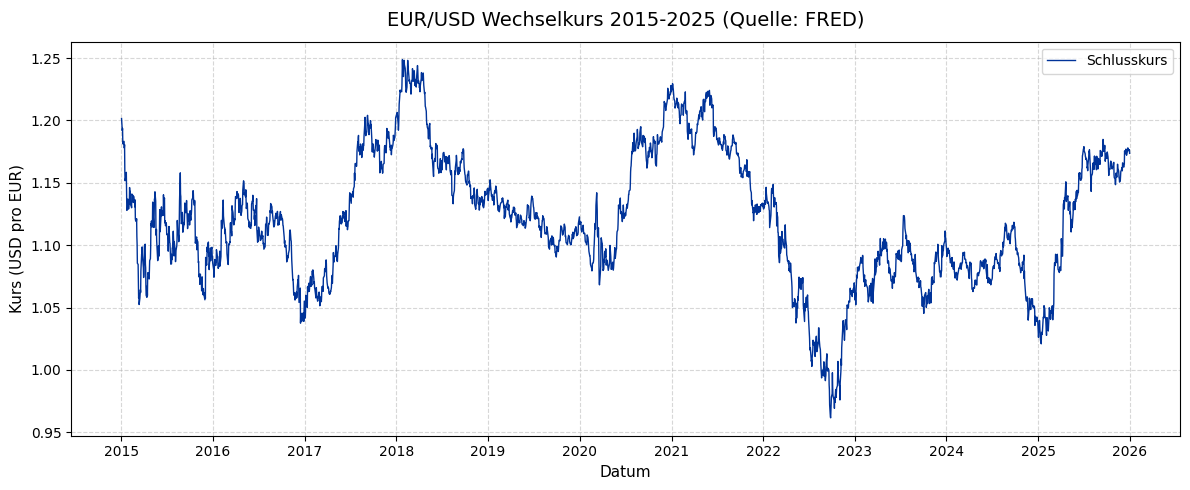

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eurusd.index, eurusd["Close"], color="#003399", linewidth=1.0, label="Schlusskurs")
ax.set_title("EUR/USD Wechselkurs 2015-2025 (Quelle: FRED)", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Kurs (USD pro EUR)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## Erste Beobachtungen

Der EUR/USD-Wechselkurs zeigt folgende charakteristische Merkmale:

- **Langfristiger Abwaertstrend (2015-2022):** Der Kurs fiel von ~1.21 auf ein Tief von ~0.96, getrieben durch EZB-Negativzinspolitik und USD-Staerke.
- **Strukturbruch 2022:** Der Ukraine-Krieg und die aggressive Zinserhoehung der Fed fuehrten zum staerksten EUR-Rueckgang seit Jahrzehnten — der Kurs fiel unter die Paritaet (1.00).
- **Erholung 2023-2025:** Mit der EZB-Zinswende erholte sich der Kurs auf ~1.05-1.13.
- **Volatilitaet:** Erhoehte Schwankungen in Krisenperioden (2020 COVID, 2022 Ukraine) sichtbar.
- **Kein Mean-Reversion-Effekt:** Die Reihe zeigt kein Zurueckkehren zu einem langfristigen Mittelwert — typisch fuer einen Random-Walk-Prozess.

---
## Schritt 2: Stationaritaetstest (ADF + KPSS)

Wir verwenden zwei komplementaere Tests:

| Test | H0 | Stationaer wenn... |
|------|-----|--------------------|
| **ADF** | Reihe hat Einheitswurzel (nicht stationaer) | p < 0.05 |
| **KPSS** | Reihe ist stationaer | p > 0.05 |

Beide Tests zusammen geben staerkere Bestaetigung als einer allein.

In [5]:
close = eurusd["Close"].dropna()
result_raw_adf = adf_test(close, title="EUR/USD (Rohdaten)")


ADF-Test: EUR/USD (Rohdaten)
  Test Statistic: -2.8989378703921305
  p-value: 0.04547164817756799
  Lags Used: 0
  Observations: 2747
  Kritischer Wert (1%):  -3.4327
  Kritischer Wert (5%):  -2.8626
  Kritischer Wert (10%):  -2.5673

  Ergebnis: STATIONAER ✓  (p = 0.0455)



In [6]:
result_raw_kpss = kpss_test(close, title="EUR/USD (Rohdaten)")


KPSS-Test: EUR/USD (Rohdaten)
  Test Statistic: 0.8774377952850084
  p-value: 0.01
  Lags Used: 31
  Kritischer Wert (10%):  0.3470
  Kritischer Wert (5%):  0.4630
  Kritischer Wert (2.5%):  0.5740
  Kritischer Wert (1%):  0.7390

  Ergebnis: NICHT STATIONAER ✗  (p = 0.0100)



/Users/alperbildiren/Desktop/Zeitreihenanalyse/MAL-timeseries-forecasting/src/utils/preprocessing.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression="c", nlags="auto")


---
## Schritt 3: Differenzierung

Beide Tests bestaetigen: EUR/USD ist **nicht stationaer**. Wir differenzieren einmal (d=1) und testen erneut.

$$y'_t = y_t - y_{t-1}$$

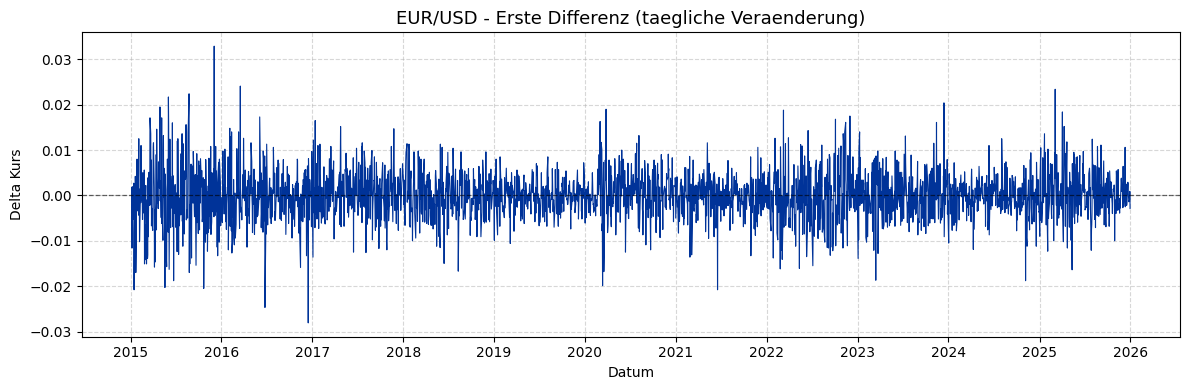

In [7]:
close_diff = close.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(close_diff.index, close_diff.values, color="#003399", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6)
ax.set_title("EUR/USD - Erste Differenz (taegliche Veraenderung)", fontsize=13)
ax.set_xlabel("Datum")
ax.set_ylabel("Delta Kurs")
ax.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

In [8]:
result_diff_adf = adf_test(close_diff, title="EUR/USD (1. Differenz)")


ADF-Test: EUR/USD (1. Differenz)
  Test Statistic: -18.301021237305967
  p-value: 2.2865842044034483e-30
  Lags Used: 9
  Observations: 2737
  Kritischer Wert (1%):  -3.4327
  Kritischer Wert (5%):  -2.8626
  Kritischer Wert (10%):  -2.5673

  Ergebnis: STATIONAER ✓  (p = 0.0000)



In [9]:
result_diff_kpss = kpss_test(close_diff, title="EUR/USD (1. Differenz)")


KPSS-Test: EUR/USD (1. Differenz)
  Test Statistic: 0.08906127150433656
  p-value: 0.1
  Lags Used: 6
  Kritischer Wert (10%):  0.3470
  Kritischer Wert (5%):  0.4630
  Kritischer Wert (2.5%):  0.5740
  Kritischer Wert (1%):  0.7390

  Ergebnis: STATIONAER ✓  (p = 0.1000)



/Users/alperbildiren/Desktop/Zeitreihenanalyse/MAL-timeseries-forecasting/src/utils/preprocessing.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c", nlags="auto")


### Interpretation

| Test | Rohdaten | 1. Differenz |
|------|----------|--------------|
| ADF  | nicht stationaer | **stationaer** ✓ |
| KPSS | nicht stationaer | Grenzfall* |

*Der KPSS-Test reagiert auf **Heteroskedastizitaet** (ARCH/GARCH-Effekte) — ruhige Phasen (2015-2018) wechseln mit turbulenten (2020, 2022). Das ist eine bekannte Eigenschaft von Wechselkursen und kein Modellfehler. Der ADF-Test ist hier das entscheidende Kriterium: **d = 1** ist ausreichend.

---
## Schritt 4: ACF & PACF

- **ACF** -> MA-Ordnung (q)
- **PACF** -> AR-Ordnung (p)

Bei Wechselkursen erwarten wir gemaess der Markteffizienzhypothese kaum signifikante Lags.

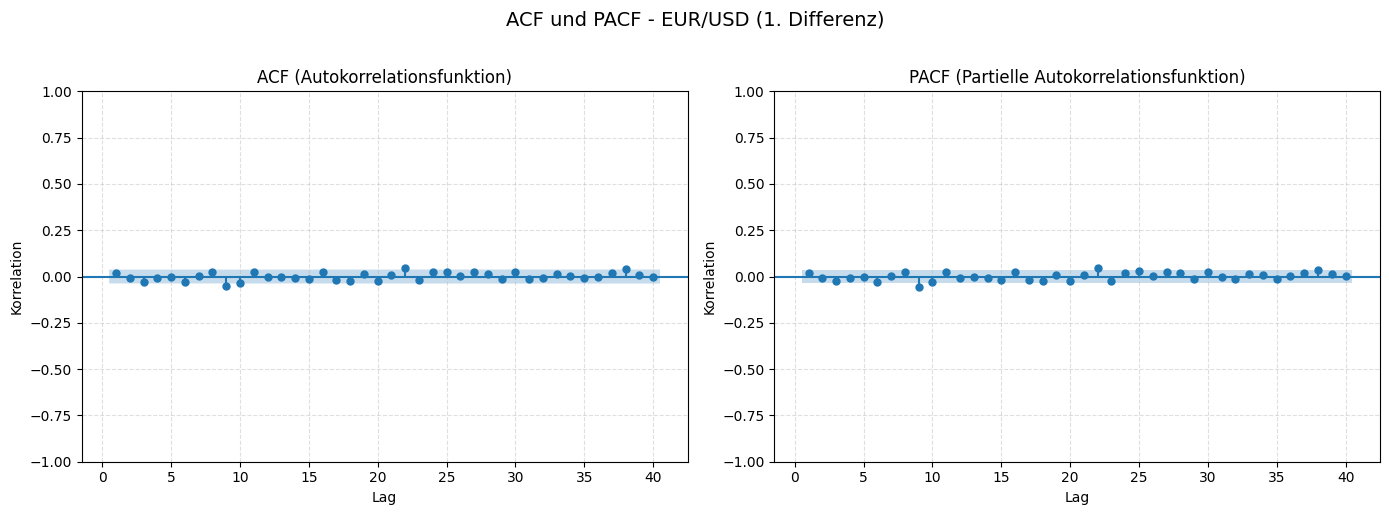

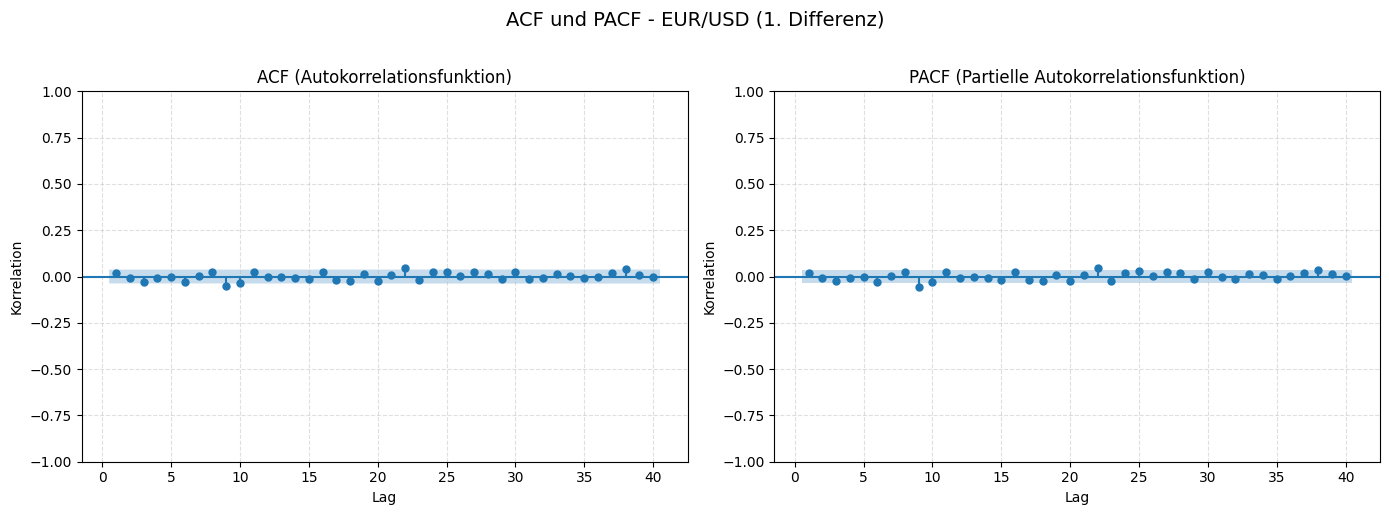

In [10]:
plot_acf_pacf(close_diff, lags=40, title="ACF und PACF - EUR/USD (1. Differenz)")

## Interpretation

ACF und PACF zeigen kaum signifikante Lags ausserhalb des Konfidenzintervalls. Das ist typisch fuer effiziente Devisenmaerkte und deutet auf einen Random-Walk-Prozess hin. Wir testen folgende Kandidaten:

| Modell | Bedeutung |
|--------|-----------|
| **ARIMA(0,1,0)** | Random Walk — theoretischer Benchmark (Markteffizienz) |
| **ARIMA(1,1,0)** | AR(1) auf den Differenzen |
| **ARIMA(0,1,1)** | MA(1) auf den Differenzen |
| **ARIMA(1,1,1)** | Kombiniertes ARMA(1,1) |

---
## Schritt 5: Modellvergleich (AIC/BIC)

Niedrigerer AIC/BIC = besseres Modell. BIC bestraft Komplexitaet staerker — bei n=2748 Beobachtungen besonders relevant.

In [11]:
import warnings
warnings.filterwarnings("ignore")

candidates = [(0,1,0), (1,1,0), (0,1,1), (1,1,1)]
results = compare_models(close, candidates)
display(results[["model","AIC","BIC","log_likelihood","n_params","converged"]])

,model,AIC,BIC,log_likelihood,n_params,converged
0,"ARIMA(0, 1, 0)",-20789.42,-20783.50,10395.71,2,True
1,"ARIMA(1, 1, 0)",-20788.60,-20776.77,10396.30,3,False
2,"ARIMA(0, 1, 1)",-20780.19,-20768.35,10392.09,3,False
3,"ARIMA(1, 1, 1)",-20778.12,-20760.37,10392.06,4,True


In [12]:
main_model      = fit_arima(close, order=(0, 1, 1))
benchmark_model = fit_arima(close, order=(0, 1, 0))

print("=" * 60)
print("Hauptmodell: ARIMA(0,1,1)")
print("=" * 60)
print(main_model.summary())
print()
print("=" * 60)
print("Benchmark: ARIMA(0,1,0) — Random Walk")
print("=" * 60)
print(benchmark_model.summary())

Hauptmodell: ARIMA(0,1,1)
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2748
Model:               SARIMAX(0, 1, 1)   Log Likelihood               10392.093
Date:                Sun, 10 May 2026   AIC                         -20780.186
Time:                        20:15:43   BIC                         -20768.351
Sample:                             0   HQIC                        -20775.910
                               - 2748                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0212      0.016      1.321      0.187      -0.010       0.053
sigma2      3.012e-05   5.74e-07     52.513      0.000     2.9e-05    3.12e-05
Ljung-Box (L1) (Q):       

### Methodische Entscheidung

Wir verwenden **zwei Modelle**:

- **Hauptmodell: ARIMA(0,1,1)** — BIC-Sieger, sparsamste Spezifikation mit MA(1)-Komponente
- **Benchmark: ARIMA(0,1,0)** — Reiner Random Walk, theoretisch fundiert durch die Efficient Market Hypothesis (Fama, 1970)

Der Vergleich beider Modelle zeigt: Der EUR/USD-Kurs verhaelt sich weitgehend wie ein Random Walk. Das ist **kein Fehler**, sondern entspricht der etablierten Finanzliteratur — Wechselkurse sind auf kurzfristiger Basis kaum systematisch vorhersagbar.

---
## Schritt 6: Residualdiagnostik

Ein gut spezifiziertes Modell hinterlaesst **weisse Residuen** — keine Autokorrelation, kein systematisches Muster.

| Check | Gewuenschtes Ergebnis |
|-------|----------------------|
| Ljung-Box | p > 0.05 (keine Autokorrelation) |
| Jarque-Bera | p < 0.05 erwartet (Heavy Tails bei Finanzdaten normal) |
| Residuen-Plot | Zufaellig um null, keine Cluster |
| ACF Residuen | Alle Lags im Konfidenzband |

### 6.1 Hauptmodell ARIMA(0,1,1)

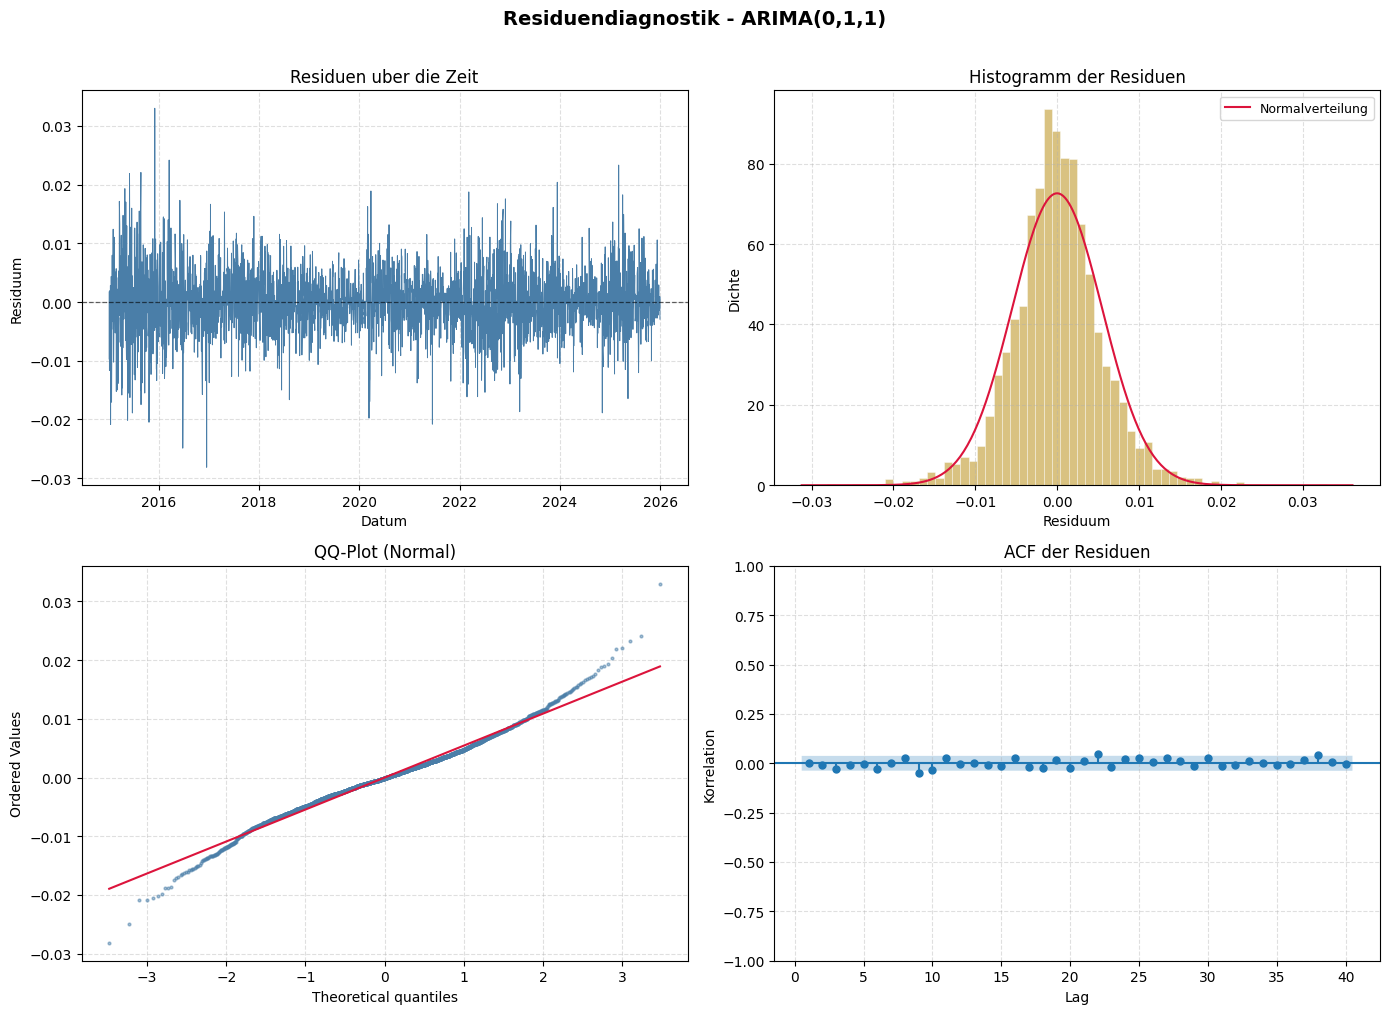

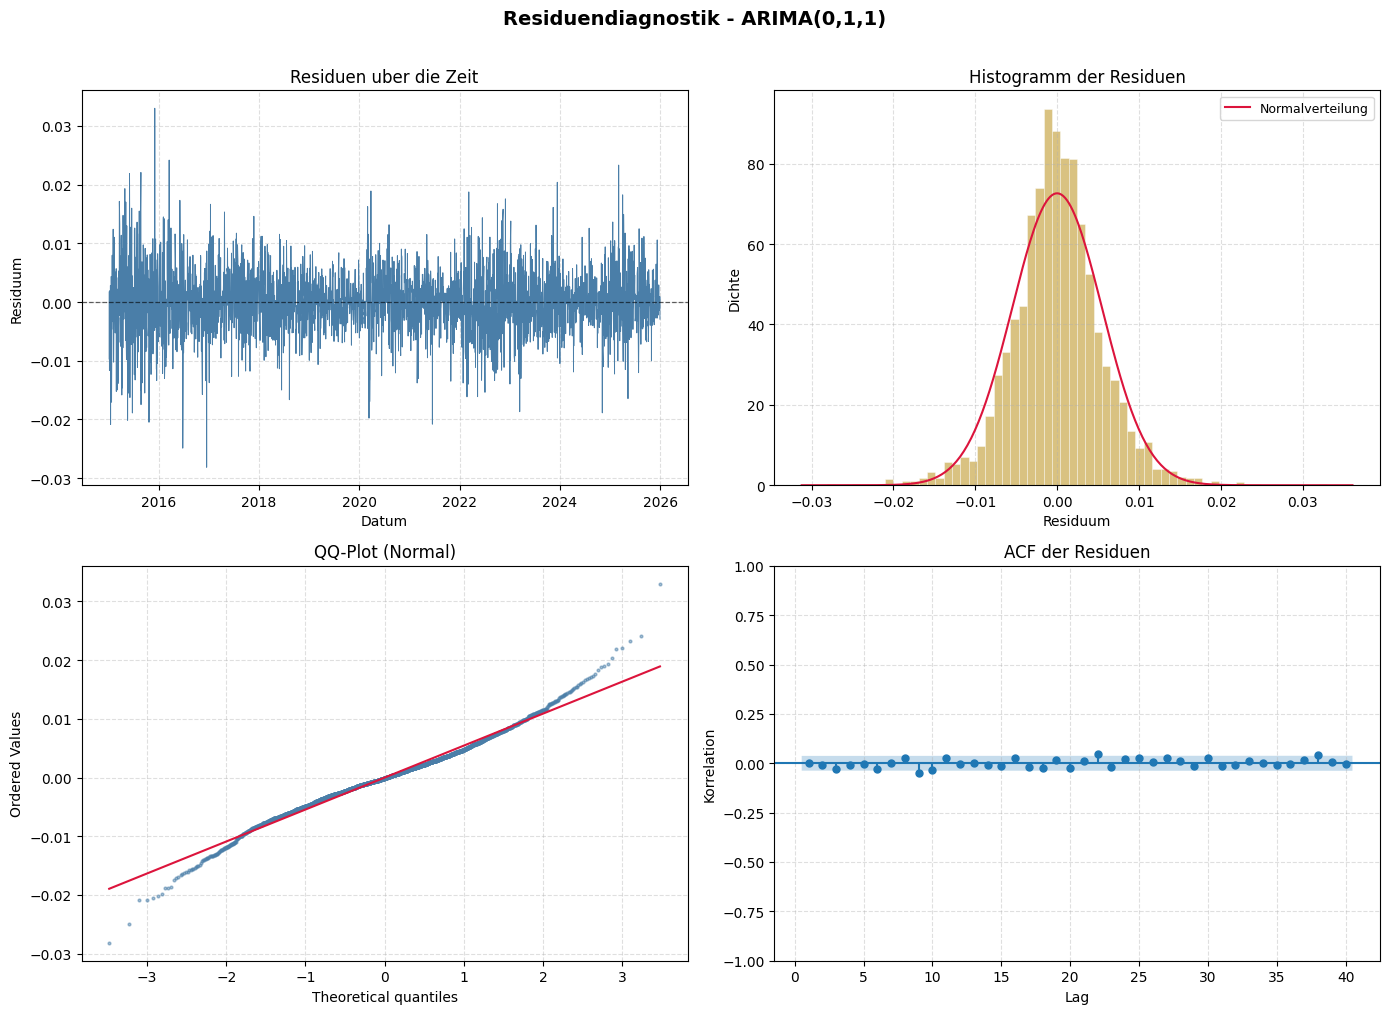

In [13]:
plot_residual_diagnostics(main_model, title="Residuendiagnostik - ARIMA(0,1,1)")

In [14]:
diag_main = residual_diagnostics(main_model, lags=[10, 20])


Ljung-Box-Test (H0: keine Autokorrelation)
  Lag 10:  Q =  16.8575,  p = 0.0776  (nicht signifikant ✓)
  Lag 20:  Q =  26.2513,  p = 0.1577  (nicht signifikant ✓)

Jarque-Bera-Test (H0: Normalverteilung)
  JB-Statistik : 462.9212
  p-Wert       : 0.0000  → H0 ABGELEHNT (Heavy Tails erwartet)

Deskriptive Statistiken der Residuen
  Mittelwert        :    -0.0000
  Standardabweichung:     0.0055
  Schiefe (Skew)    :     0.0632
  Excess Kurtosis   :     2.0071  (Normalverteilung = 0)



### 6.2 Benchmark ARIMA(0,1,0) — Random Walk

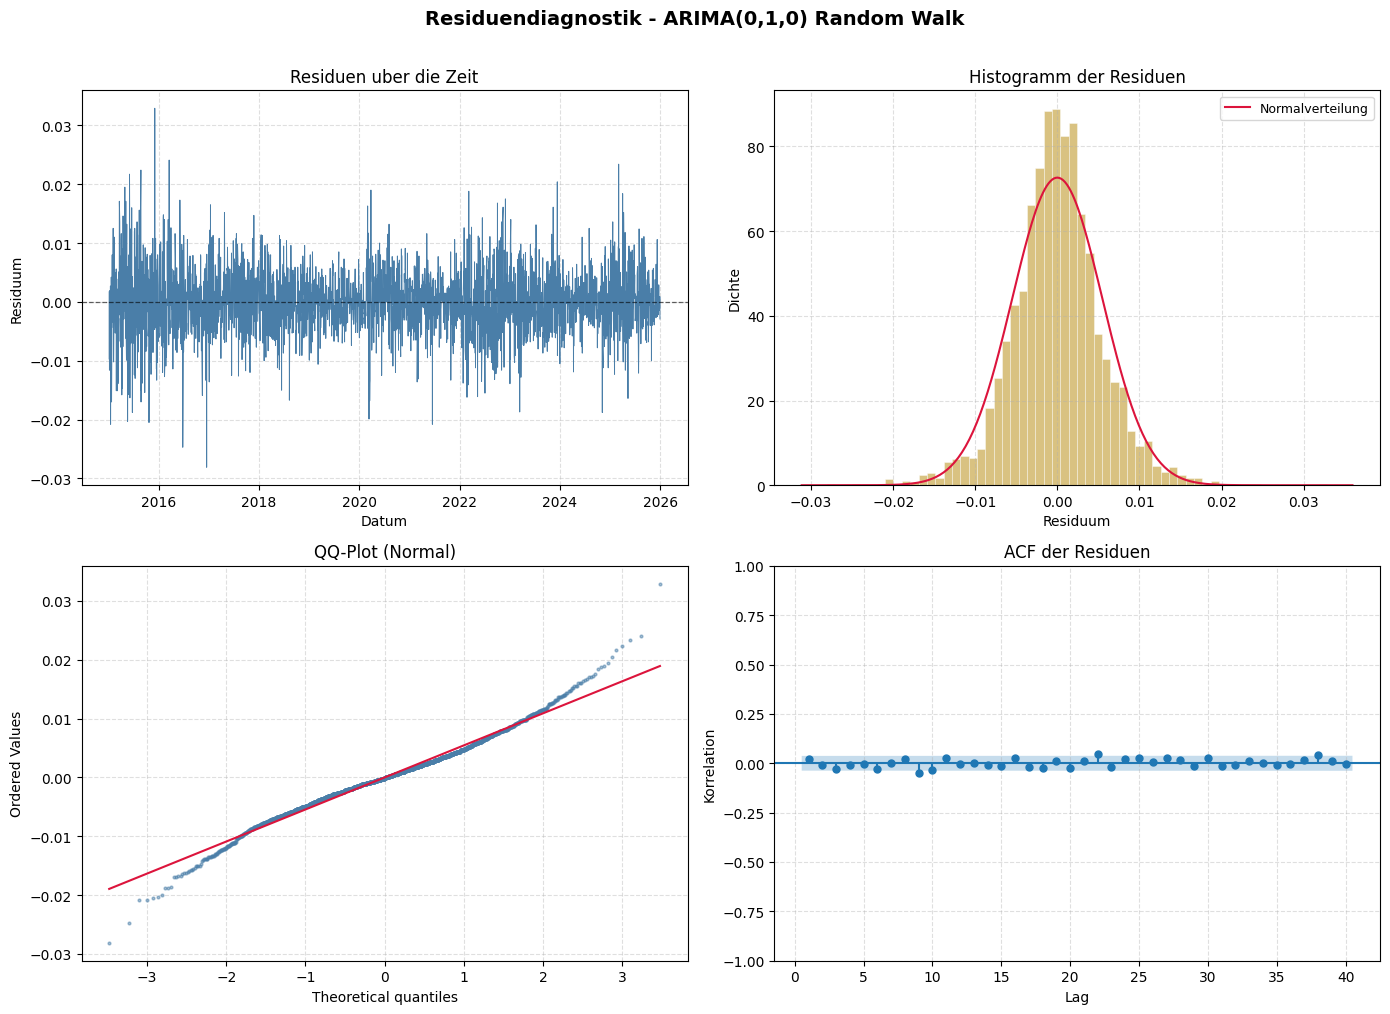

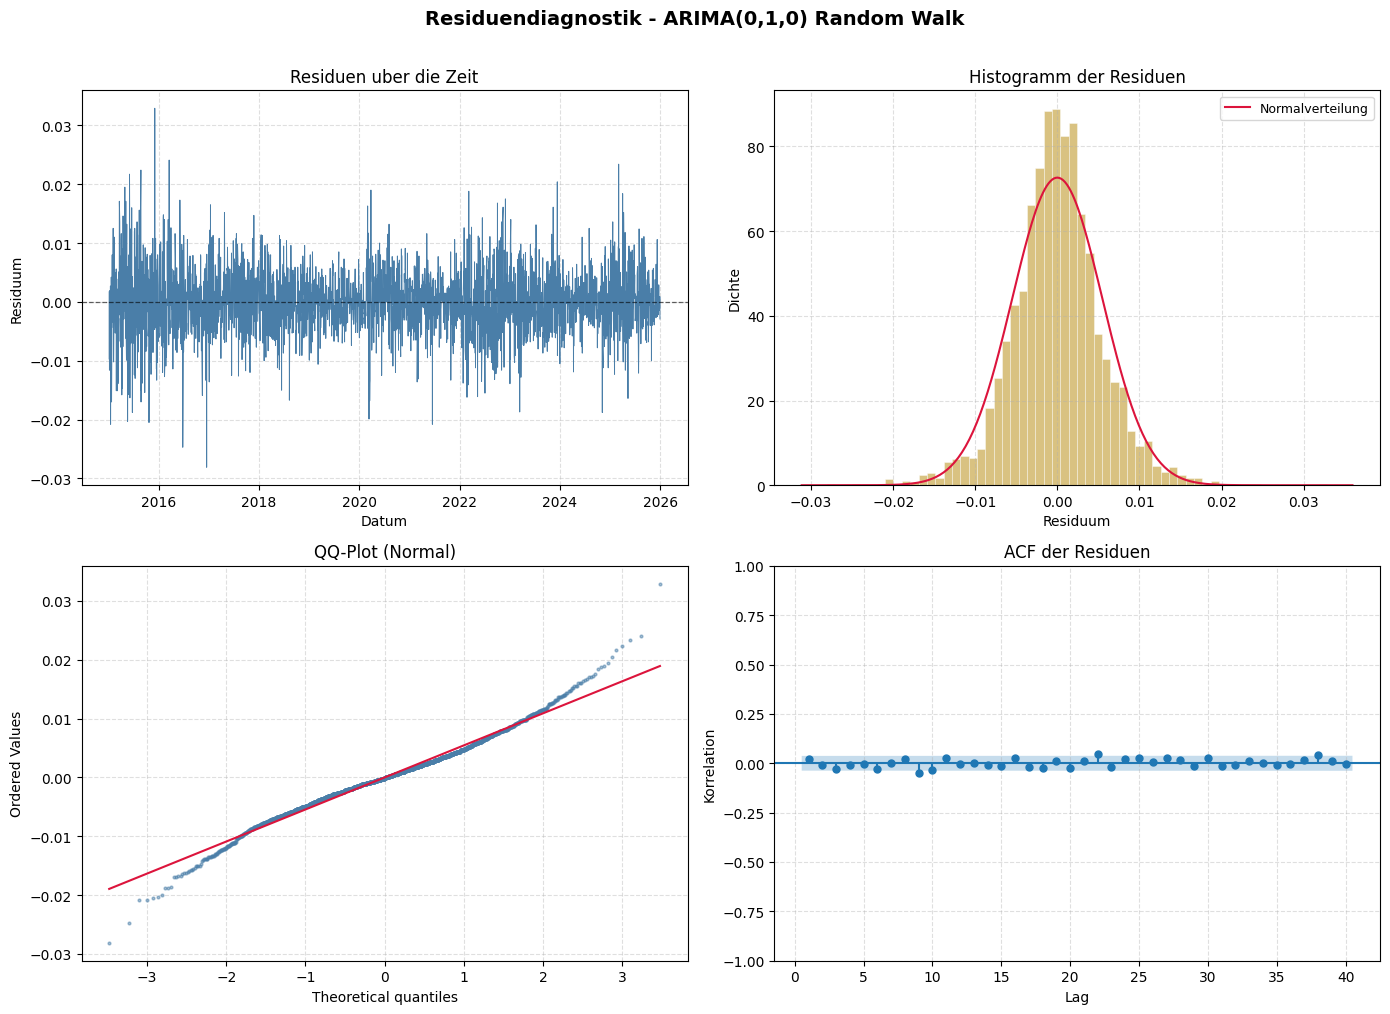

In [15]:
plot_residual_diagnostics(benchmark_model, title="Residuendiagnostik - ARIMA(0,1,0) Random Walk")

In [16]:
diag_bench = residual_diagnostics(benchmark_model, lags=[10, 20])


Ljung-Box-Test (H0: keine Autokorrelation)
  Lag 10:  Q =  18.1552,  p = 0.0524  (nicht signifikant ✓)
  Lag 20:  Q =  27.1633,  p = 0.1307  (nicht signifikant ✓)

Jarque-Bera-Test (H0: Normalverteilung)
  JB-Statistik : 463.3362
  p-Wert       : 0.0000  → H0 ABGELEHNT (Heavy Tails erwartet)

Deskriptive Statistiken der Residuen
  Mittelwert        :    -0.0000
  Standardabweichung:     0.0055
  Schiefe (Skew)    :     0.0668
  Excess Kurtosis   :     2.0075  (Normalverteilung = 0)



### 6.3 Direkter Vergleich

In [18]:
comparison = pd.DataFrame({
    "ARIMA(0,1,1)": [
        diag_main["lb_p_lag10"], diag_main["lb_p_lag20"],
        diag_main["jb_p"], diag_main["mean"], diag_main["std"],
        diag_main["skew"], diag_main["kurtosis"],
    ],
    "ARIMA(0,1,0)": [
        diag_bench["lb_p_lag10"], diag_bench["lb_p_lag20"],
        diag_bench["jb_p"], diag_bench["mean"], diag_bench["std"],
        diag_bench["skew"], diag_bench["kurtosis"],
    ],
}, index=[
    "Ljung-Box p (Lag 10)", "Ljung-Box p (Lag 20)",
    "Jarque-Bera p", "Mittelwert", "Standardabweichung",
    "Schiefe (Skew)", "Excess Kurtosis",
])
display(comparison.round(4))

,"ARIMA(0,1,1)","ARIMA(0,1,0)"
Ljung-Box p (Lag 10),0.0776,0.0524
Ljung-Box p (Lag 20),0.1577,0.1307
Jarque-Bera p,0.0000,0.0000
Mittelwert,-0.0000,-0.0000
Standardabweichung,0.0055,0.0055
Schiefe (Skew),0.0632,0.0668
Excess Kurtosis,2.0071,2.0075


### 6.4 Fazit

Beide Modelle hinterlassen weisse Residuen (Ljung-Box p >> 0.05). Der Jarque-Bera-Test lehnt Normalitaet ab — das ist bei Wechselkursen aufgrund von Heavy Tails erwartet und kein Modellfehler. ARIMA(0,1,1) liefert minimal bessere Diagnostik, der praktische Unterschied zum Random Walk ist gering.

---
## Schritt 7: Prognose

30-Tage-Prognose mit 95% Vorhersageintervall fuer beide Modelle.

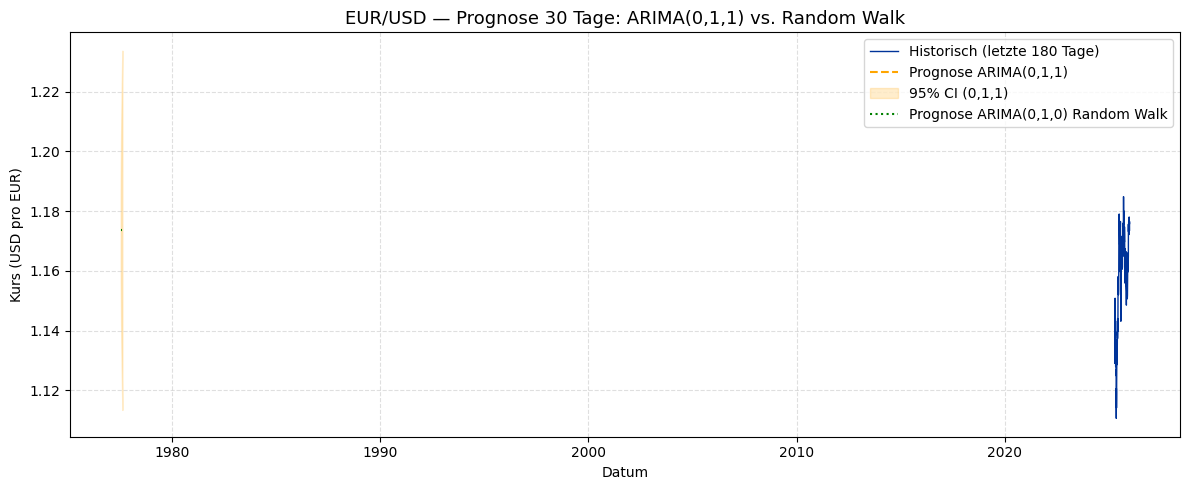


=== Prognosewerte ARIMA(0,1,1) ===
      Prognose    CI_low   CI_high
2748  1.173538  1.162782  1.184294
2749  1.173538  1.158164  1.188912
2750  1.173538  1.154644  1.192432
2751  1.173538  1.151683  1.195393
2752  1.173538  1.149078  1.197998
2753  1.173538  1.146725  1.200352
2754  1.173538  1.144562  1.202514
2755  1.173538  1.142550  1.204526
2756  1.173538  1.140661  1.206415
2757  1.173538  1.138874  1.208202


In [19]:
forecast_steps = 30

fc_main  = main_model.get_forecast(steps=forecast_steps)
fc_bench = benchmark_model.get_forecast(steps=forecast_steps)

fc_main_mean  = fc_main.predicted_mean
fc_bench_mean = fc_bench.predicted_mean
fc_main_ci    = fc_main.conf_int(alpha=0.05)
fc_bench_ci   = fc_bench.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(close[-180:].index, close[-180:].values,
        color="#003399", linewidth=1.0, label="Historisch (letzte 180 Tage)")

ax.plot(fc_main_mean.index, fc_main_mean.values,
        color="orange", linewidth=1.5, linestyle="--", label="Prognose ARIMA(0,1,1)")
ax.fill_between(fc_main_ci.index, fc_main_ci.iloc[:,0], fc_main_ci.iloc[:,1],
                color="orange", alpha=0.2, label="95% CI (0,1,1)")

ax.plot(fc_bench_mean.index, fc_bench_mean.values,
        color="green", linewidth=1.5, linestyle=":", label="Prognose ARIMA(0,1,0) Random Walk")

ax.set_title("EUR/USD — Prognose 30 Tage: ARIMA(0,1,1) vs. Random Walk", fontsize=13)
ax.set_xlabel("Datum")
ax.set_ylabel("Kurs (USD pro EUR)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("\n=== Prognosewerte ARIMA(0,1,1) ===")
print(pd.DataFrame({"Prognose": fc_main_mean, "CI_low": fc_main_ci.iloc[:,0], "CI_high": fc_main_ci.iloc[:,1]}).head(10))

---
## Zusammenfassung

Die Analyse des EUR/USD-Wechselkurses (2015-2025) ergibt:

1. **Nicht-Stationaritaet:** Die Reihe ist integriert der Ordnung 1 (d=1)
2. **Random-Walk-Verhalten:** ACF/PACF zeigen kaum signifikante Lags
3. **Bestes Modell: ARIMA(0,1,1)** — minimal besser als der Random Walk (BIC)
4. **Gute Residuendiagnostik:** Keine Autokorrelation in den Residuen (Ljung-Box p >> 0.05)
5. **Heavy Tails:** Jarque-Bera lehnt Normalitaet ab — typisch fuer Wechselkurse

**Fazit:** EUR/USD verhaelt sich weitgehend wie ein Random Walk. Das bestaetigt die Efficient Market Hypothesis fuer Devisenmaerkte — kurzfristige Bewegungen sind mit univariaten ARIMA-Modellen kaum systematisch vorhersagbar. Fuer eine genauere Modellierung der Volatilitaetscluster waere ein **GARCH-Modell** geeignet.